In [1]:
import os
import sys
import joblib
import re
import random
import copy
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

# Metadata

## флаги отладки, ускоряющие повторный прогон
**NB!:** при полном прогоне все флаги установлены в `True`, кроме `running_in_cloud` - в зависимости от платформы

In [2]:
running_in_cloud = False          # дополнительный прогон может быть на VM с GPU в облаке (без локальных сейвов)
download_wikitext = True          # выбор источника датасета - интернет ресурсы библиотеки или локальный сейв
run_LSTM_model = True             # если False, то модель загрузится из сейва последней эпохи до переобучения
run_GRU_model = True              # а история всех эпох - из ее последнего сейва (включая эпохи переобучения)
download_gpt_model = True

## глобальные параметры выполнения кода

In [3]:
# Фиксируем seed для воспроизводимости
random.seed(42)
torch.manual_seed(42)

# параметры формирования данных
seq_len_thres = 32           # длина последовательности токенов в объектах данных (инференс модели на seq_len_thres-1)
vocab_len_thres = 70000      # задаваемая длина словаря наиболее частых токенов-слов в корпусе текстов данных выше

# глобальные параметры обучения
learning_rate = 0.001        
nof_epochs = 7               

# Этап 1.  Загрузка и подготовка данных


## loading dataset

In [4]:

if download_wikitext:
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1")
    if not running_in_cloud:
        joblib.dump(dataset, os.path.join('.','data','wikitext2dataset.joblib'))
else:
    if running_in_cloud:
        sys.exit(
    'FYI: debug flags mismatch: you are supposed to load data from the net when rinning in the cloud')
    else:
        dataset = joblib.load(os.path.join('.','data','wikitext2dataset.joblib'))

## first look at data

In [5]:
dataset

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

In [6]:
dataset['train']

Dataset({
    features: ['text'],
    num_rows: 36718
})

In [7]:
print(type(dataset['train']['text']))                    # проверим тип данных
print('='*80, '\n')

print(dataset['train']['text'][:5])                      # топ списка
print('='*80, '\n')
      
for i, s in enumerate(dataset['train']['text'][:5]):   # выведем поэлементно с нумерацией
    if len(s) == 0:
        print(i, '  ', '<empty string>')                 # сделаем видимыми пустые строки
    else:
        print(i, '  ', s)
print('='*80, '\n')

for i, s in enumerate(dataset['train']['text'][:10]):
    s = s.strip('\n').strip()                        # похоже, строки списка содержат "\n" на конце и пробелы
    if len(s) == 0:
        print(i, '  | len in words =', str(len(s.split())).rjust(3), '|  ', '<empty string>')
    else:
        print(i, '  | len in words =', str(len(s.split())).rjust(3), '|  ', s)

<class 'list'>

['', ' = Valkyria Chronicles III = \n', '', ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n', " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the

## len-EDA

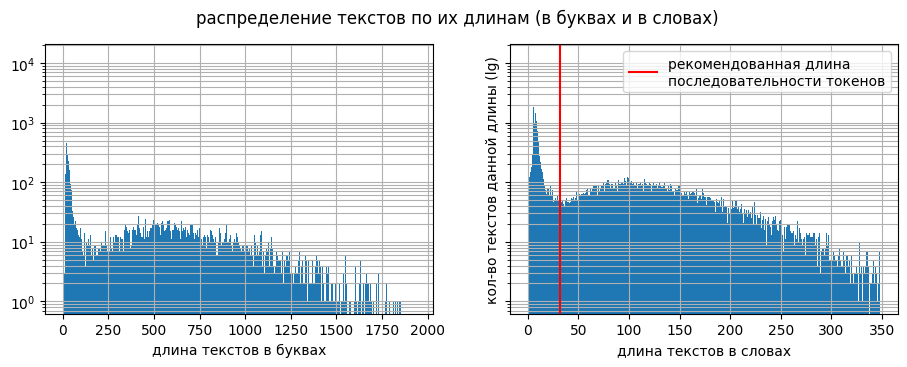

In [8]:
len_in_chars = [ len(el) for el in dataset['train']['text'] ]
len_in_words = [ len(el.split()) for el in dataset['train']['text'] ]

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(11,3.5), sharey=True)

ax1.hist(len_in_chars, bins=range(max(len_in_chars)//2))
ax1.set_yscale('log')
ax1.grid(which='both')
ax1.set_xlabel('длина текстов в буквах')

ax2.hist(len_in_words, bins=range(max(len_in_words)//2))
ax2.set_yscale('log')
ax2.grid(which='both')
ax2.set_xlabel('длина текстов в словах')
ax2.set_ylabel('кол-во текстов данной длины (lg)')
ax2.axvline(seq_len_thres, color='red', label='рекомендованная длина\nпоследовательности токенов')
ax2.legend(loc='upper right')

fig.suptitle('распределение текстов по их длинам (в буквах и в словах)')
plt.show()

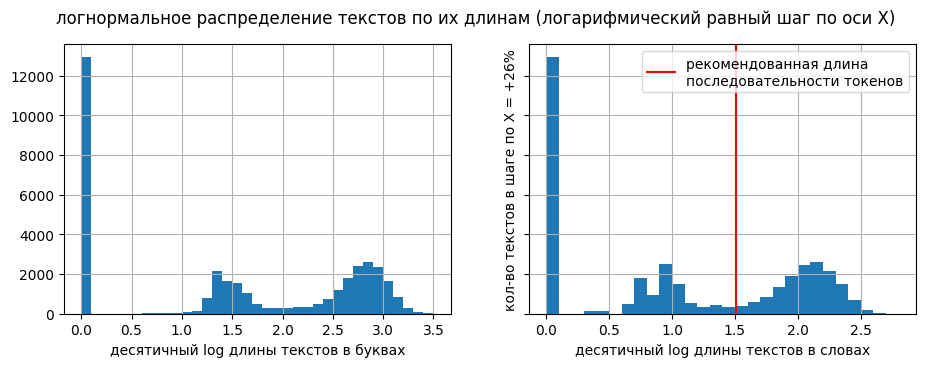

In [9]:
lg_len_in_chars = np.log(np.array(len_in_chars)+1) / np.log(10)   # если убрать прибавление 1, то код будет работать,
lg_len_in_words = np.log(np.array(len_in_words)+1) / np.log(10)   # но полностью исчезнет нулевая мода на графиках

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(11,3.5), sharey=True)

ax1.hist(lg_len_in_chars, bins=[ 0.1*i for i in range(int(max(lg_len_in_chars)*10)+1)] )
ax1.grid(which='both')
ax1.set_xlabel('десятичный log длины текстов в буквах')

ax2.hist(lg_len_in_words, bins=[ 0.1*i for i in range(int(max(lg_len_in_words)*10)+1)] )
ax2.grid(which='both')
ax2.set_xlabel('десятичный log длины текстов в словах')
ax2.set_ylabel('кол-во текстов в шаге по X = +'+str(round((10**0.1-1)*100))+'%')
ax2.axvline(np.log(seq_len_thres)/np.log(10), color='red', label='рекомендованная длина\nпоследовательности токенов')
ax2.legend(loc='upper right')

fig.suptitle('логнормальное распределение текстов по их длинам (логарифмический равный шаг по оси X)')
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
* В логнормальных координатах отчетливо выявляются три моды текстов:
  * совсем короткие, практически все они просто пустые
  * короткие - порядка десятка слов
  * полные - порядка сотни слов и длиннее
* `np.log(x)` справляется и с нулевым аргументом, выдавая минус бесконечность, которую не отрисует `matplotlib`, но мы добавляли к x +1 под логарифмом - чтобы вернуть на график все тексты.
* Рекомендуемая длина последовательности токенов 32 при предлагаемой токенизации словами идеально фильтрует только последнюю моду, удаляя две другие как шум - что разумно, так как статистика (и логика за ней) фразообразования в каждой моде, скорее всего, разная:  примерно также, как статистика продолжения фразы на заборе сильно отличается от таковой в художественном романе!

## raw preprocessing
теперь, когда минимальную длину текста в словах мы обосновали, можно проводить большую чистку данных 

In [10]:
def raw_preproc(raw_texts_list, len_thres):
    # удаляем слишком короткие тексты
    texts = [line for line in raw_texts_list if len(line.split()) >= len_thres]

    # функция для "чистки" текстов (из материалов урока)
    def clean_string(text):
        # приведение к нижнему регистру
        text = text.lower()
        # удаление всего, кроме латинских букв, цифр и пробелов
        text = re.sub(r'[^a-z0-9\s]', '', text)
        # удаление дублирующихся пробелов, удаление пробелов по краям
        text = re.sub(r'\s+', ' ', text).strip()
    
        return text

    # "чистим" тексты
    cleaned_texts_list = list(map(clean_string, texts))
    # повторно "обрезаем" коротких
    return [line for line in cleaned_texts_list if len(line.split()) >= len_thres]

### применяем функцию чистки к train/val/test спискам текстов

In [11]:
train_texts = raw_preproc(dataset['train']['text'], seq_len_thres)  
test_texts = raw_preproc(dataset['test']['text'], seq_len_thres)
val_texts = raw_preproc(dataset['validation']['text'], seq_len_thres)

len(train_texts), len(val_texts), len(test_texts)

(14344, 1519, 1726)

### оцениваем потери в данных после очистки

In [12]:
print('Осталось после чистки текстов:')
print('='*30)
print('train      ','val        ','test')
print('-'*30)
print(round(len(train_texts) / len(dataset['train']) *100,1), '%     ',
      round(len(val_texts) / len(dataset['validation']) *100,1), '%     ',
      round(len(test_texts) / len(dataset['test']) *100,1), '%')

Осталось после чистки текстов:
train       val         test
------------------------------
39.1 %      40.4 %      39.6 %


In [13]:
for i, s in enumerate(train_texts[:10]):
    print(i, '  | len =', str(len(s.split())).rjust(3), '|  ', s)

0   | len = 107 |   senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january 2011 in japan it is the third game in the valkyria series employing the same fusion of tactical and real time gameplay as its predecessors the story runs parallel to the first game and follows the nameless a penal military unit serving the nation of gallia during the second europan war who perform secret black operations and are pitted against the imperial unit calamaty raven
1   | len =  82 |   the game began development in 2010 carrying over a large portion of the work done on valkyria chronicles ii while it retained the standard features of the series it also underwent multiple adjustments such as making the game more forgiving for series newcomers character designer raita honjou and composer hitosh

## собираем словарь для токенизации словами
для словаря не помешает объединить все данные

In [14]:
corpus = train_texts + val_texts + test_texts

counter = Counter()

for text in corpus:
    counter.update(text.split())

# список слов в порядке убывания частоты
words = [word for word, freq in counter.most_common()]

# список частот в том же порядке
freqs = [freq for word, freq in counter.most_common()]

print('Full dictionary length for word-tokenization was', len(freqs))
print('Top10 most frequent tokens are:', words[:10])

Full dictionary length for word-tokenization was 70075
Top10 most frequent tokens are: ['the', 'of', 'and', 'in', 'to', 'a', 'was', 'on', 'as', 'that']


### посмотрим как словарь распределился по частотам

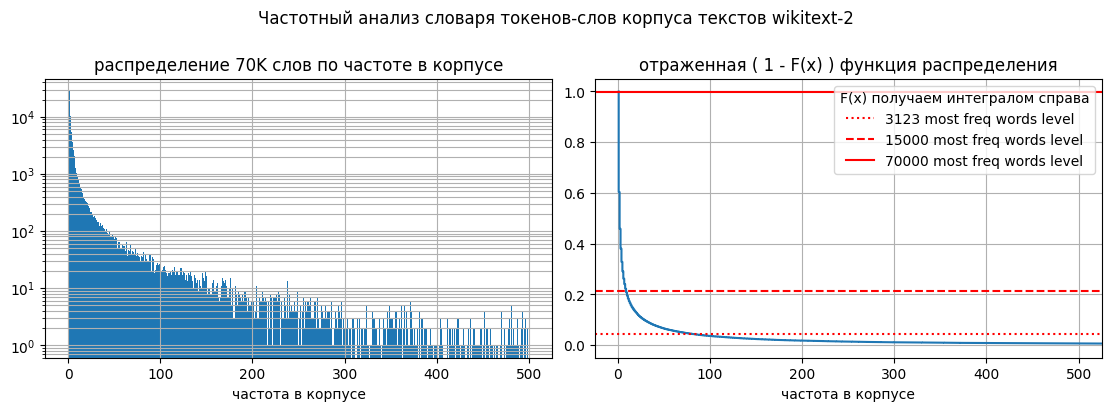

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharex=True, layout='constrained')

ax1.hist( freqs, bins=range(500) )
ax1.set_yscale('log')
ax1.grid(which='both')
ax1.set_title('распределение 70K слов по частоте в корпусе')
ax1.set_xlabel('частота в корпусе')

ax2.plot(freqs, [i/len(freqs) for i in range(1, len(freqs)+1)] )
ax2.axhline(3123/len(freqs), color='red', ls=':', label='3123 most freq words level')
ax2.axhline(15000/len(freqs), color='red', ls='--', label='15000 most freq words level')
ax2.axhline(vocab_len_thres/len(freqs), color='red', label=str(vocab_len_thres)+' most freq words level')
ax2.set_xlim(-25,525)
ax2.grid()
ax2.legend(title='F(x) получаем интегралом справа', loc='upper right')
ax2.set_title('отраженная ( 1 - F(x) ) функция распределения')
ax2.set_xlabel('частота в корпусе')

fig.suptitle('Частотный анализ словаря токенов-слов корпуса текстов wikitext-2\n')
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
* 30К слов из 70К встречаются во всем корпусе только 1 раз!
* 80% слов встречаются во всем корпусе реже 10 раз и навряд ли могут быть индивидуально запомнены моделью
* но замена их всех на OoV-токен сделает этот токен невероятно частым и он может начать попадать в рекомендации
* поэтому хотелось бы сделать его более естественно выглядящим в рекомендации модели - этакий джокер или слово-паразит: "типа", "этахрень", "well", "voila", "imho"

проверим "voila" - подойдет: его нет в корпусе!

In [16]:
'voila' in words, 'voil' in words       # слово могло обрезать французское написание последней буквы "voil`a"

(False, False)

### подбираем оптимальную отсечку по частоте (NB!: позднее корректируется!)
идея та же, что в оптимальном балансе precision-recall через максимум метрики f1

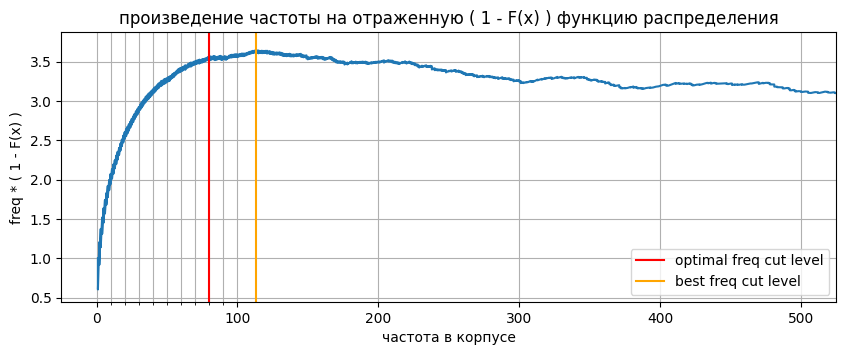

In [17]:
plt.figure(figsize=(10,3.5))
plt.plot(freqs, np.array(freqs) * np.array([i/len(freqs) for i in range(1, len(freqs)+1)]) )
plt.axvline(80, color='red', label='optimal freq cut level')
plt.axvline(113, color='orange', label='best freq cut level')
plt.xlim(-25,525)
plt.xticks(range(0,100,10), minor=True)
plt.grid(which='both')
plt.legend(loc='lower right')
plt.title('произведение частоты на отраженную ( 1 - F(x) ) функцию распределения')
plt.ylabel('freq * ( 1 - F(x) )')
plt.xlabel('частота в корпусе')


plt.show()

**ВЫВОДЫ ИЗ ГРАФИКА:**
* максимум площади под графиком отраженной функции распределения достигается при freq = 113
* однако, там широкое плато, поэтому за оптимальную отсечку принимаем частоту 80, где площадь начинает уже уверенно деградировать

In [18]:
print('Оптимальная длина словаря на данном корпусе текстов:   vocab_len_thres =', len([f for f in freqs if f >= 80]))

Оптимальная длина словаря на данном корпусе текстов:   vocab_len_thres = 3123


**ЗАМЕЧАНИЯ ПО БОЛЕЕ ПОЗДНИМ КОРРЕКЦИЯМ**
* указанная проблема, что в текстах очень большой словарный запас и большая часть слов используется редко и с синонимами не позволяет эффективно использовать OoV-токен, так как его доля получается проценты и даже десятки процентов - в любом случае модель будет обучаться на тривиальную, которая просто предсказывает voila всегда, так как естественный рейт OoV-токена выше точности модели, сколько не обучай
* так что в итоге взяли размер словаря 70К
* забавный момент - указывает на природу популярности слов-паразитов у людей с невысоким интеллектом!

### ну и собственно словари: `words_encoder` & `words_decoder`

In [19]:
print('FYI: actual vocab_len_thres is set to:', vocab_len_thres)

FYI: actual vocab_len_thres is set to: 70000


In [20]:
words_encoder = dict(zip(words[:vocab_len_thres], range(vocab_len_thres)))
words_decoder = dict(zip(range(vocab_len_thres), words[:vocab_len_thres]))

# добавим voila
words_encoder['voila'] = vocab_len_thres
words_decoder[vocab_len_thres] = 'voila'

## texts encoding & "voila" substitution for OoV-words

### сперва нужно сделать замену редких на "voila"

In [21]:
black_list = set(words[vocab_len_thres:])

voila_train_texts, voila_val_texts, voila_test_texts = [], [], []
data_type = ['train data','val data','test data']

for i, (output, input) in enumerate([(voila_train_texts, train_texts),  
                                     (voila_val_texts, val_texts),      
                                     (voila_test_texts, test_texts)]):  
    print('Handling', data_type[i])
    
    for s in input:
        new_s_list = []
        for w in s.split():
            if w in black_list:
                new_s_list.append('voila')
            else:
                new_s_list.append(w)
        output.append(' '.join(new_s_list))
    
print('FYI: all done!')


len(voila_train_texts), len(voila_val_texts), len(voila_test_texts)

Handling train data
Handling val data
Handling test data
FYI: all done!


(14344, 1519, 1726)

### проверим, не много ли voila

In [22]:
for i in range(8):
    print(i, '  | len =', str(len(train_texts[i].split())).rjust(4), '|  ', train_texts[i])
    print(i, '  | len =', str(len(voila_train_texts[i].split())).rjust(4), '|  ', voila_train_texts[i])
    print('-'*80)

0   | len =  107 |   senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january 2011 in japan it is the third game in the valkyria series employing the same fusion of tactical and real time gameplay as its predecessors the story runs parallel to the first game and follows the nameless a penal military unit serving the nation of gallia during the second europan war who perform secret black operations and are pitted against the imperial unit calamaty raven
0   | len =  107 |   senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january 2011 in japan it is the third game in the

**ВЫВОДЫ**
* здесь пришлось вернуться и откорректировать порог отсечки: причина в том, что тексты написаны хорошим языком, с использованием синонимов и широкого набора терминов (обладателями словарного запаса в несколько десятков тысяч слов), поэтому в районе отсечки с частотой 80 еще очень много общеупотребительных слов (nameless, chronicles, tactical, battlefield, scouts, soldier, switch и т.д.) попадает в OoV-токен
* перенеся порог с 3К до 15К слов, мы понизили порог отсечки по частоте до 10
* при новом пороге 15К видим, что voila заменяют либо редкие слова (senj(o), unrecorded, gallian, echelons, 422), либо ошибки в написании (europen, valkyira, shocktrupper) 
* строго говоря, хорошо бы помимо формальной предобработки провести еще схлопывание синонимов (для повышения частотности) и коррекцию орфографических ошибок (для того же) - тогда хватило бы и 5К и обучение было бы более уверенным.  А так для слов с частотой 10 обучение обещает быть слабым!
* однако и 15К оказалось на практике плохо - дело в том, что если закодировать 70К - 15К = 55К слов одним OoV-токеном, то модель будет самообучаться на предпочтительное предсказание только его: слишком велик естественный рейт у одного варианта из 15К!

## сборка numpy-массивов из 32-словных последовательностей, заодно и кодирование
Идея сборки словами:
* вытягивать весь список текстов в одну строку и нарезать ее по 32 слова - плохо, так как будет много последовательностей, включающих начало и конец из несвязанных между собой текстов
* поэтому пойдем по-текстно, но при этом будет много хвостов короче 32 слов - что с ними.  Можно просто отбросить, но человеку свойственно в конце абзаца резюмировать мысль, поэтому для последнего отрезка в 32 слов будет отмерять его с конца.

### напишем функцию, которая одновременно делит один текст на фрагменты по 32 слова и делает их кодирование по индексу словаря
и сразу проверим ее работу

In [23]:
def text_to_numpy(text, seq_len = 32):
    idx = 0
    seq_list = []

    encoded_list = [words_encoder[el] for el in text.split()]
    
    while idx + seq_len < len(encoded_list):
        seq_list.append(np.array(encoded_list[idx : idx + seq_len]))
        idx += seq_len
    
    seq_list.append(np.array(encoded_list[-seq_len:]))

    return np.stack(seq_list)

print(voila_train_texts[0])
print('='*70)
print(f'after converting into 32-words sequences and encoding (voila = {vocab_len_thres}):')
text_to_numpy(voila_train_texts[0])

senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and mediavision for the playstation portable released in january 2011 in japan it is the third game in the valkyria series employing the same fusion of tactical and real time gameplay as its predecessors the story runs parallel to the first game and follows the nameless a penal military unit serving the nation of gallia during the second europan war who perform secret black operations and are pitted against the imperial unit calamaty raven
after converting into 32-words sequences and encoding (voila = 70000):


array([[20352,    74,  4342,    80, 22963,  4059,   417,    80,  6243,
         4342,     1,     0,  5313,    80,  1996,   963,     4,     8,
         4342,  4059,   977,   589,   735,    14,     5,  5625,   280,
          582,   245,    60,   405,    13],
       [ 5314,     2, 22964,    11,     0,  1997,  5626,   152,     3,
          210,   358,     3,   735,    17,    14,     0,   222,    60,
            3,     0,  4342,    92,  7778,     0,   150,  4786,     1,
         5625,     2,   763,    48,  2594],
       [    8,    31,  7189,     0,   348,   933,  2877,     4,     0,
           29,    60,     2,  1869,     0, 11005,     5, 16829,   271,
          866,  2014,     0,  1762,     1, 18331,    43,     0,    91,
        26626,    87,    42,  1826,  1649],
       [    2,  1869,     0, 11005,     5, 16829,   271,   866,  2014,
            0,  1762,     1, 18331,    43,     0,    91, 26626,    87,
           42,  1826,  1649,   289,   523,     2,    26, 12118,    99,
            0,  

### используя проверенную функцию соберем все массивы

In [24]:
train_numpy_seq_list, val_numpy_seq_list, test_numpy_seq_list = [], [], []
data_type = ['train data','val data','test data']

for i, (output, input) in enumerate([(train_numpy_seq_list, voila_train_texts),  
                                     (val_numpy_seq_list, voila_val_texts),      
                                     (test_numpy_seq_list, voila_test_texts)]):  
    print('Handling', data_type[i])
    
    for s in input:
        output.append(text_to_numpy(s))

train_numpy_array = np.concatenate(train_numpy_seq_list, axis=0)
val_numpy_array = np.concatenate(val_numpy_seq_list, axis=0)    
test_numpy_array = np.concatenate(test_numpy_seq_list, axis=0)   
    
print('FYI: all done!')


train_numpy_array.shape, val_numpy_array.shape, test_numpy_array.shape

Handling train data
Handling val data
Handling test data
FYI: all done!


((60082, 32), (6312, 32), (7112, 32))

## собираем объекты организации данных для обучения в torch

### наследуем класс torch `Dataset`

In [ ]:
class WikiTextDataset(Dataset):
    # в конструкторе просто сохраняем все данные 
    def __init__(self, np_arr):
        self.texts = np.copy(np_arr[:,:-1])
        self.labels = np.copy(np_arr[:,1:])

    # метод __len__ возвращает количество объектов в датасете
    def __len__(self):
        return len(self.texts)

    # метод __getitem__ возвращает элемент датасета с индексом idx
    def __getitem__(self, idx):
        # получаем текст и его класс по индексу
        text = self.texts[idx]
        label = self.labels[idx]
        
        # padding нам не нужен, так как все строки одинаковой длины уже
        
        # возвращаем текст и класс
        return {
            'input_seq': torch.tensor(text, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long)
        }

### создаем объекты датасетов для всех трех групп train/val/test

In [26]:
train_dataset = WikiTextDataset(train_numpy_array)
val_dataset = WikiTextDataset(val_numpy_array)
test_dataset = WikiTextDataset(test_numpy_array)

### и наконец, создаем загрузчики батчей

In [27]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=512, shuffle=False)


# Этап 2. Реализация и обучение LSTM

## класс LSTM-модели

In [28]:
class WikiTextLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=256, num_layers=2, dropout=0.25):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(input_size=emb_dim, hidden_size=hidden_dim, num_layers=num_layers, 
                            batch_first=True, dropout=dropout, bidirectional=False)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

        self.init_weights()


    def init_weights(self):
        nn.init.xavier_uniform_(self.fc.weight)
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)


    def forward(self, input_ids):
        x = self.embedding(input_ids)
        lstm_out, _ = self.lstm(x)
        lstm_out_normed = self.norm(lstm_out)
        out = self.dropout(lstm_out_normed)
        logits = self.fc(out)

        return logits

## инстанс модели, оптимизатор и функция потерь

In [29]:
# создание модели
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_lstm = WikiTextLSTM(vocab_size=vocab_len_thres+1).to(device)

# создание оптимизатора и функции потерь
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

## цикл обучения с выделением под-функций

### выделяем код одной эпохи и функцию валидации

In [30]:
# код обучения одной эпохи
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in tqdm(loader):
        ids = batch['input_seq'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(ids)

        # для задачи предсказания следующего слова форма функции потерь модифицируется так:        
        loss = criterion(logits.view(-1, vocab_len_thres+1), labels.view(-1))
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

In [31]:
# код подсчёта accuracy на валидации
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            ids = batch['input_seq'].to(device)
            labels = batch['label']
            logits = model(ids)

            # для задачи предсказания следующего слова форма функции потерь модифицируется так:
            loss = criterion(logits.view(-1, vocab_len_thres+1), labels.view(-1))
            
            total_loss += loss.item()
    return total_loss / len(loader), np.exp(total_loss / len(loader))

### сам цикл

In [ ]:
# обучение
lstm_train_history = []
if run_LSTM_model:
    for epoch in range(nof_epochs):
        epoch_start = datetime.now()
        train_loss = train_epoch(model_lstm, train_dataloader, optimizer_lstm)
        val_loss, perp = evaluate(model_lstm, val_dataloader)
        epoch_stop = datetime.now()

        lstm_train_history.append((train_loss, val_loss, perp, round((epoch_stop-epoch_start).total_seconds())))
        
        print(f"Epoch {epoch+1}:  ", 
              f"Avg via epoch Train Loss = {train_loss:.4f} | ", 
              f"Final epoch end Val Loss = {val_loss:.4f} | ", 
              f"Perplexity = {perp:.4f}")
        
        if not running_in_cloud:            # будем сохранять модель после каждой эпохи для early stopping 
            torch.save(model_lstm.state_dict(), os.path.join('.','models','lstm_model_dict_epoch_'+str(epoch)+'.save'))
            joblib.dump(lstm_train_history, os.path.join('.','models','lstm_train_history_epoch_'+str(epoch)+'.save'))

        if epoch == 4:
            best_model_state = copy.deepcopy(model_lstm.state_dict())   # сохраняем веса наилучшей модели в памяти
        elif epoch == nof_epochs - 1:
            model_lstm.load_state_dict(best_model_state)                # восстанавливаем модель наилучшей эпохи
else:
    if running_in_cloud:
        sys.exit('FYI: debug flags mismatch: you are not supposed to save/load models when rinning in the cloud')
    else:
        model_lstm.load_state_dict(torch.load(os.path.join('.','models','lstm_model_dict_epoch_4.save')))
        lstm_train_history = joblib.load(os.path.join('.','models',
                                                      'lstm_train_history_epoch_'+str(nof_epochs - 1)+'.save'))
        
        for epoch in range(len(lstm_train_history)):
            train_loss, val_loss, perp, epoch_runtime = lstm_train_history[epoch]
            print(f"Epoch {epoch+1} run {epoch_runtime} seconds:  ", 
                  f"Avg via epoch Train Loss = {train_loss:.4f} | ", 
                  f"Final epoch end Val Loss = {val_loss:.4f} | ", 
                  f"Perplexity = {perp:.4f}")

100%|██████████| 939/939 [24:29<00:00,  1.57s/it]


Epoch 1:   Avg via epoch Train Loss = 7.5513 |  Final epoch end Val Loss = 7.0744 |  Perplexity = 1181.3098


100%|██████████| 939/939 [24:27<00:00,  1.56s/it]


Epoch 2:   Avg via epoch Train Loss = 6.7384 |  Final epoch end Val Loss = 6.9350 |  Perplexity = 1027.6228


100%|██████████| 939/939 [24:27<00:00,  1.56s/it]


...

Epoch 5:   Avg via epoch Train Loss = 5.9602 |  Final epoch end Val Loss = 6.9031 |  Perplexity = 995.3251


100%|██████████| 939/939 [24:51<00:00,  1.59s/it]


Epoch 6:   Avg via epoch Train Loss = 5.7809 |  Final epoch end Val Loss = 6.9159 |  Perplexity = 1008.1938


100%|██████████| 939/939 [24:58<00:00,  1.60s/it]


Epoch 7:   Avg via epoch Train Loss = 5.6192 |  Final epoch end Val Loss = 6.9380 |  Perplexity = 1030.7180


**ВЫВОДЫ:**
* переобучение начинается после 5й эпохи, поэтому за лучшую модель выбираем сейв от 5й эпохи
* неопределенность выбора ответа сузилась от 70К до 1К, но все равно этого не достаточно для бизнес кейса персонального Т9
* можно порекомендовать в реализацию начало показа подсказки после первой введенной буквы нового слова - тогда количество вариантов падает в 25 раз, ужимая perplexity на уровень 40

## оценим результаты визуально

In [33]:
X_val = val_numpy_array[:256,:-1]
y_val = val_numpy_array[:256,1:]

model_lstm.eval()

WikiTextLSTM(
  (embedding): Embedding(70001, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.25)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=256, out_features=70001, bias=True)
)

In [34]:
y_pred_LSTM = np.argmax(model_lstm(torch.tensor(X_val, dtype=torch.long)).detach().numpy(), axis=2)

In [35]:
view_df = pd.DataFrame(
             index=['actual word in text', 'predicted by LSTM'],
             data=[
                   list(y_val.flatten()),
                   list(y_pred_LSTM.flatten())
    ]
).T

for col in view_df.columns:       # а теперь декодируем номера классов обратно в слова
    view_df[col] = view_df[col].map(lambda n: words_decoder[n] if n >= 0 else 'NA')

view_df['LSTM match'] = view_df['actual word in text'] == view_df['predicted by LSTM']

print(' '*12, 'ONE TEXT FROM VALIDATION DATASET:')
view_df.head(31)                  # развернем первую последовательность вертикально

             ONE TEXT FROM VALIDATION DATASET:


,actual word in text,predicted by LSTM,LSTM match
0,gammarus,and,False
1,known,the,False
2,as,as,True
3,the,the,True
4,european,sun,False
5,lobster,union,False
6,or,and,False
7,common,the,False
8,lobster,starlings,False
9,is,is,True


**ВЫВОДЫ:**
* модель неплохо справляется в предиктом типичных связок предлогов, союзов, артиклей и даже клише:
  * known -> as the
  * it -> is a
  * parts -> of the
  * is -> a
  * from -> the
  * species -> of
  * european -> union (тут, правда, не угадала - текст про лобстеров, а не про политиков, но клише понятно!)
* хотя для практического юзкейса подсказок петимотов (petits mots) маловато, но сам факт, что вот так за два с половиной часа на лаптопе можно обучить мини-мозг базовым связкам языка - это, конечно, впечатляет!
* кстати, поскольку эти маленькие слова являются лидерами по частотности, то accuracy получается неплохой для выбора из 70К вариантов ответов - одно попадание на 6 выстрелов !! Это круче чем сомнения perplexity = 1K (в остальных 5 из 6 случаев)
* пример текста вскрывает основную проблему исходного датасета - 14К текстов про что угодно на свете - маловато будет: поэтому тема лобстеров осталась не раскрытой! 

In [36]:
print('LSTM accuracy on the first 256 sequences in the validation dataset =', 
      round(view_df['LSTM match'].mean() *100, 1),'%')

LSTM accuracy on the first 256 sequences in the validation dataset = 15.5 %


# Этап 3. Эксперимент: GRU vs LSTM

## класс GRU-модели

In [37]:
class WikiTextGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=256, num_layers=2, dropout=0.25):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(input_size=emb_dim, hidden_size=hidden_dim, num_layers=num_layers, 
                            batch_first=True, dropout=dropout, bidirectional=False)
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

        self.init_weights()


    def init_weights(self):
        nn.init.xavier_uniform_(self.fc.weight)
        for name, param in self.gru.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)


    def forward(self, input_ids):
        x = self.embedding(input_ids)
        gru_out, _ = self.gru(x)
        gru_out_normed = self.norm(gru_out)
        out = self.dropout(gru_out_normed)
        logits = self.fc(out)

        return logits

## инстанс модели, оптимизатор и функция потерь

In [38]:
# создание модели
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_gru = WikiTextGRU(vocab_size=vocab_len_thres+1).to(device)

# создание оптимизатора и функции потерь
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

## цикл обучения с переиспользованием ранее выделенных под-функций
Заметим, что функции цикла одной эпохи и валидации модели полностью переиспользуются

In [ ]:
# обучение
gru_train_history = []
if run_GRU_model:
    for epoch in range(nof_epochs):
        epoch_start = datetime.now()
        train_loss = train_epoch(model_gru, train_dataloader, optimizer_gru)
        val_loss, perp = evaluate(model_gru, val_dataloader)
        epoch_stop = datetime.now()
        
        gru_train_history.append((train_loss, val_loss, perp, round((epoch_stop-epoch_start).total_seconds())))
        
        print(f"Epoch {epoch+1}:  ", 
              f"Avg via epoch Train Loss = {train_loss:.4f} | ", 
              f"Final epoch end Val Loss = {val_loss:.4f} | ", 
              f"Perplexity = {perp:.4f}")
        
        if not running_in_cloud:            # будем сохранять модель после каждой эпохи для early stopping 
            torch.save(model_gru.state_dict(), os.path.join('.','models','gru_model_dict_epoch_'+str(epoch)+'.save'))
            joblib.dump(gru_train_history, os.path.join('.','models','gru_train_history_epoch_'+str(epoch)+'.save'))
        
        if epoch == 4:
            best_model_state = copy.deepcopy(model_gru.state_dict())   # сохраняем веса наилучшей модели в пямяти
        elif epoch == nof_epochs - 1:
            model_gru.load_state_dict(best_model_state)                # восстанавливаем модель наилучшей эпохи
else:
    if running_in_cloud:
        sys.exit('FYI: debug flags mismatch: you are not supposed to save/load models when rinning in the cloud')
    else:
        model_gru.load_state_dict(torch.load(os.path.join('.','models','gru_model_dict_epoch_4.save')))
        gru_train_history = joblib.load(os.path.join('.','models',
                                                     'gru_train_history_epoch_'+str(nof_epochs - 1)+'.save'))
        
        for epoch in range(len(gru_train_history)):
            train_loss, val_loss, perp, epoch_runtime = gru_train_history[epoch]
            print(f"Epoch {epoch+1} run {epoch_runtime} seconds:  ", 
                  f"Avg via epoch Train Loss = {train_loss:.4f} | ", 
                  f"Final epoch end Val Loss = {val_loss:.4f} | ", 
                  f"Perplexity = {perp:.4f}")

100%|██████████| 939/939 [25:16<00:00,  1.61s/it]


Epoch 1:   Avg via epoch Train Loss = 7.5481 |  Final epoch end Val Loss = 7.0849 |  Perplexity = 1193.8075


100%|██████████| 939/939 [25:13<00:00,  1.61s/it]


Epoch 2:   Avg via epoch Train Loss = 6.7348 |  Final epoch end Val Loss = 6.9668 |  Perplexity = 1060.8152


100%|██████████| 939/939 [25:14<00:00,  1.61s/it]


...

Epoch 5:   Avg via epoch Train Loss = 5.9021 |  Final epoch end Val Loss = 6.9460 |  Perplexity = 1038.9394


100%|██████████| 939/939 [25:19<00:00,  1.62s/it]


Epoch 6:   Avg via epoch Train Loss = 5.7120 |  Final epoch end Val Loss = 6.9772 |  Perplexity = 1071.9427


100%|██████████| 939/939 [25:22<00:00,  1.62s/it]


Epoch 7:   Avg via epoch Train Loss = 5.5462 |  Final epoch end Val Loss = 7.0287 |  Perplexity = 1128.5830


## графики обучения GRU vs LSTM

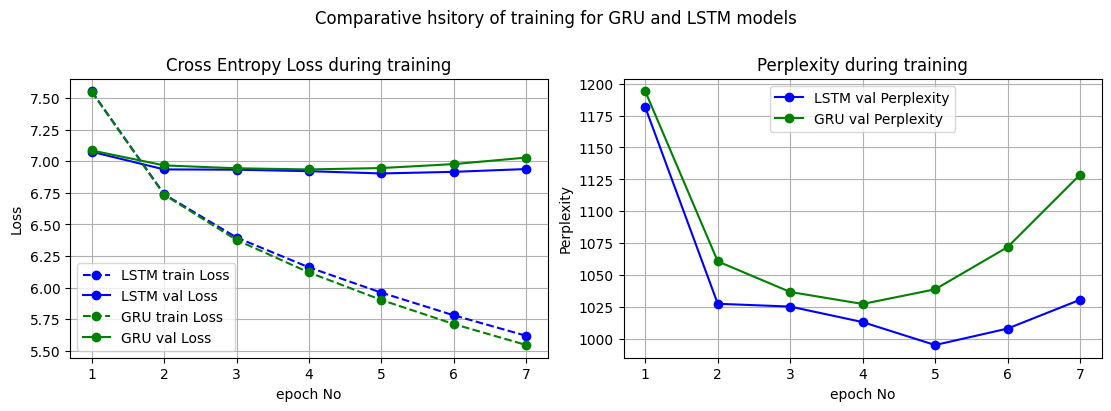

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,4), layout='constrained')

ax1.plot(range(1,len(lstm_train_history)+1), np.array(lstm_train_history)[:,0], 
         color='blue', marker='o', label='LSTM train Loss', ls='--')
ax1.plot(range(1,len(lstm_train_history)+1), np.array(lstm_train_history)[:,1], 
         color='blue', marker='o', label='LSTM val Loss')
ax1.plot(range(1,len(gru_train_history)+1), np.array(gru_train_history)[:,0], 
         color='green', marker='o', label='GRU train Loss', ls='--')
ax1.plot(range(1,len(gru_train_history)+1), np.array(gru_train_history)[:,1], 
         color='green', marker='o', label='GRU val Loss')
ax1.set_xlabel('epoch No')
ax1.set_ylabel('Loss')
ax1.set_title('Cross Entropy Loss during training')
ax1.legend(loc='lower left')
ax1.grid()

ax2.plot(range(1,len(lstm_train_history)+1), np.array(lstm_train_history)[:,2], 
         color='blue', marker='o', label='LSTM val Perplexity')
ax2.plot(range(1,len(gru_train_history)+1), np.array(gru_train_history)[:,2], 
         color='green', marker='o', label='GRU val Perplexity')
ax2.set_xlabel('epoch No')
ax2.set_ylabel('Perplexity')
ax2.set_title('Perplexity during training')
ax2.legend(loc='upper center')
ax2.grid()

fig.suptitle('Comparative hsitory of training for GRU and LSTM models\n')
plt.show()

## сравним GRU vs LSTM

In [41]:
model_gru.eval()

WikiTextGRU(
  (embedding): Embedding(70001, 128)
  (gru): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.25)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=256, out_features=70001, bias=True)
)

In [42]:
y_pred_GRU = np.argmax(model_gru(torch.tensor(X_val, dtype=torch.long)).detach().numpy(), axis=2)

In [43]:
view_df['predicted by GRU'] = list(y_pred_GRU.flatten())
view_df['predicted by GRU'] = view_df['predicted by GRU'].map(lambda n: words_decoder[n] if n >= 0 else 'NA')
view_df['GRU match'] = view_df['actual word in text'] == view_df['predicted by GRU']
view_df['LSTM vs GRU match'] = view_df['predicted by LSTM'] == view_df['predicted by GRU']

print(' '*33, 'ONE TEXT FROM VALIDATION DATASET:')
view_df.head(31)                  # развернем первую последовательность вертикально

                                  ONE TEXT FROM VALIDATION DATASET:


,actual word in text,predicted by LSTM,LSTM match,predicted by GRU,GRU match,LSTM vs GRU match
0,gammarus,and,False,of,False,False
1,known,the,False,s,False,False
2,as,as,True,as,True,True
3,the,the,True,the,True,True
4,european,sun,False,fountain,False,False
5,lobster,union,False,star,False,False
6,or,and,False,and,False,True
7,common,the,False,the,False,True
8,lobster,starlings,False,starling,False,False
9,is,is,True,the,False,False


In [44]:
print('LSTM accuracy on the first 256 sequences in the validation dataset =', 
      round(view_df['LSTM match'].mean() *100, 1),'%')
print('GRU accuracy on the first 256 sequences in the validation dataset =', 
      round(view_df['GRU match'].mean() *100, 1),'%')
print('LSTM vs GRU match on the first 256 sequences in the validation dataset =', 
      round(view_df['LSTM vs GRU match'].mean() *100, 1),'%')

LSTM accuracy on the first 256 sequences in the validation dataset = 15.5 %
GRU accuracy on the first 256 sequences in the validation dataset = 15.2 %
LSTM vs GRU match on the first 256 sequences in the validation dataset = 59.4 %


In [45]:
nofp_lstm = sum(p.numel() for p in model_lstm.parameters())
nofp_gru = sum(p.numel() for p in model_gru.parameters())

print('Total number of parameters in LSTM:', nofp_lstm)
print('Total number of parameters in GRU:', nofp_gru)
print('difference about', round(200*(nofp_lstm-nofp_gru)/(nofp_lstm+nofp_gru),2), '%')

Total number of parameters in LSTM: 27872497
Total number of parameters in GRU: 27642097
difference about 0.83 %


**также интересно сравнить "словарный запас" в предсказаниях моделей**

In [46]:
print('В 256 последовательностях валидационной разметки всего было:', len(set(list(y_val.flatten()))), 'разных слов')
print('В 256 рекомендациях LSTM модели на валидации осталось:', 
      len(set(list(np.argmax(model_lstm(torch.tensor(X_val, dtype=torch.long)).detach().numpy(), axis=2).flatten()))), 
      'разных слов')
print('В 256 рекомендациях GRU модели на валидации осталось:', 
      len(set(list(np.argmax(model_gru(torch.tensor(X_val, dtype=torch.long)).detach().numpy(), axis=2).flatten()))), 
      'разных слов')

В 256 последовательностях валидационной разметки всего было: 2105 разных слов
В 256 рекомендациях LSTM модели на валидации осталось: 287 разных слов
В 256 рекомендациях GRU модели на валидации осталось: 386 разных слов


**ВЫВОДЫ ПО СРАВНЕНИЮ LSTM vs GRU МОДЕЛЕЙ:**
* модели довольно близки по всем параметрам, но LSTM немного лучше, хотя у GRU шире вариативность (неуместно) предлагаемых слов.  При этом обе модели согласны друг с другом в своем предсказании на 59% 
* скорость обучения не отличается: 25 минут на одну эпоху на CPU (AMD Ryzen 5 3.8 GHz) и 32GB DDR4, early-stop на 5 эпохе
* объемы сейвов весов отличаются менее чем на 1% - равно, как и число параметров: причина в огромном выходном слое - большая часть параметров на нем, вне слоя nn.LSTM или nn.GRU
* уменьшить выходной слой, чтобы стали заметнее разница в сложности между nn.LSTM и nn.GRU эффективно не получается, так как тогда модели все сильнее сваливаются в константное предсказание OoV-токеном (из-за слишком большого естественного рейта последнего при обрезании словаря)
* чтобы обнаружить разницу надо увеличить число параметров на внутренних слоях - но мы и так на пределе скорости обучения (один e2e прогон за ночь на CPU)

# Этап 4. Оценка distilgpt2

## загрузка токинезатора и модели `distilgpt2`

In [65]:
if download_gpt_model:
    model_name = "distilgpt2"
    tokenizer_gpt = GPT2TokenizerFast.from_pretrained(model_name)
    model_gpt = GPT2LMHeadModel.from_pretrained(model_name)

    if not running_in_cloud:
        joblib.dump(tokenizer_gpt, os.path.join('.','models','gpt_tokenizer_save,joblib'))
        joblib.dump(model_gpt, os.path.join('.','models','gpt_model_save,joblib'))

else:
    if running_in_cloud:
        sys.exit('FYI: debug flags mismatch: you are not supposed to save/load models when rinning in the cloud')
    else:
        tokenizer_gpt = joblib.load(os.path.join('.','models','gpt_tokenizer_save,joblib'))
        model_gpt = joblib.load(os.path.join('.','models','gpt_model_save,joblib'))

model_gpt.eval()      # используем только для инференса

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

**а тут внутренних слоев гораздо больше!!**

## стараемся представить выход GPT2 максимально похожим образом для сравнения с LSTM и GRU

### сперва готовим те же данные на вход GPT2

In [73]:
X_val = val_numpy_array[:256,:-1]
X_val

array([[ 7003,  7989,   112, ...,   536,    17,    14],
       [ 1020,     4,     0, ...,     5,  9973,  1278],
       [ 5850,     3,   189, ...,     4,     5,    76],
       ...,
       [   43,     0,   123, ...,    47,   292,  1282],
       [   12,   741, 41314, ...,   129,     4,  9841],
       [  306,     4,  3346, ...,  1871,     4,  1539]], shape=(256, 31))

In [74]:
X_val_text = []

for i in range(len(X_val)):
    X_val_text.append(' '.join([words_decoder[class_no] for class_no in X_val[i,:]]))

X_val_text[:5]

['homarus gammarus known as the european lobster or common lobster is a species of clawed lobster from the eastern atlantic ocean mediterranean sea and parts of the black sea it is',
 'related to the american lobster h americanus it may grow to a length of 60 cm 24 in and a mass of 6 kilograms 13 lb and bears a conspicuous pair',
 'claws in life the lobsters are blue only becoming lobster red on cooking mating occurs in the summer producing eggs which are carried by the females for up to a year',
 'by the females for up to a year before hatching into planktonic larvae homarus gammarus is a highly esteemed food and is widely caught using lobster pots mostly around the british',
 'homarus gammarus is a large crustacean with a body length up to 60 centimetres 24 in and weighing up to 5 6 kilograms 11 13 lb although the lobsters caught in']

### теперь токинезируем и скармливаем модели
модель, видимо, обучена на длинах последовательностей слов-токенов больше нашей, поэтому разрешаем паддинг 

In [75]:
tokenizer_gpt.pad_token = tokenizer_gpt.eos_token
inputs = tokenizer_gpt(X_val_text, return_tensors='pt', padding=True, truncation=False)
outputs = model_gpt(**inputs)

In [76]:
outputs['logits'].shape

torch.Size([256, 48, 50257])

**NB!:** заметим, что axis=1 у логитов на выходе GPT2 имеет *разную длину* - в зависимости от того батча, который подали на вход модели.  Что свидетельствует о *других таргетах модели GTP2*.  Это основная принципиальная разница, сильно препятствующая прямому сравнению ответов скачанного GPT2 с ответами наших реализаций LSTM и GRU: в нашей реализации в ответе всегда 31 слово как в разметке, а у GTP2 там будет 50 +/- 10 *BPE-токенов* и как их оптимально сгруппировать в 31 группу для прямого сравнения - ХЗ!  Придется на глазок - задействовать свои биологическую NN!

### смотрим что на выходе

In [77]:
gpt_predictions = pd.DataFrame()

for i in range(outputs['logits'].shape[1]):
    next_ids = outputs['logits'][:,i,:].argmax(dim=-1)
    next_words = tokenizer_gpt.batch_decode(next_ids, skip_special_tokens=True)
    gpt_predictions[i] = next_words

gpt_predictions = gpt_predictions.map(lambda s: s.lower())
print(' '*10, 'ВЕРТИКАЛЬНО РАСПОЛОЖЕНЫ 256 ДЕМО-ПРИМЕРОВ ПОСЛЕДОВАТЕЛЬНОСТЕЙ ВАЛИДАЦИОННОЙ ВЫБОРКИ:')
gpt_predictions.T

           ВЕРТИКАЛЬНО РАСПОЛОЖЕНЫ 256 ДЕМО-ПРИМЕРОВ ПОСЛЕДОВАТЕЛЬНОСТЕЙ ВАЛИДАЦИОННОЙ ВЫБОРКИ:


,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
0,the,the,the,the,the,the,the,the,the,the,...,the,the,the,the,the,the,the,the,the,the
1,.,the,.,same,.,not,light,the,time,way,...,of,.,ar,.,few,ed,.,first,.,the
2,ut,extent,the,are,ut,the,the,to,of,that,...,to,.,.,the,discussion,",",.,an,.,for
3,",",an,.,the,",",-,to,make,the,one,...,be,the,-,point,in,make,the,.,m,.
4,",",community,way,to,",",.,make,the,aces,",",...,in,",",.,wealth,the,a,highways,war,in,the
5,as,industry,sters,a,a,tall,the,the,gr,is,...,to,1930,in,.,economy,bases,.,movement,@,2016
6,the,ound,are,year,very,inches,the,new,ods,been,...,the,collapse,be,the,.,.,.,.,son,.
7,"""",an,the,.,",",cm,new,that,",",ened,...,new,year,a,the,the,that,the,the,",",ched
8,pe,.,",",they,of,diameter,that,�,a,edges,...,that,depression,apartments,.,end,gers,popular,united,ue,by
9,an,alian,.,atching,an,",",�,ot,with,.,...,that,.,the,rim,of,and,in,s,",",fact


### похоже, что знаки препинания и кавычки надо вычистить

In [78]:
all_cleared_preds = []

for i in range(len(gpt_predictions)):
    cleared_preds = [el for el in gpt_predictions.values[i,:] if el not in ('.',',','"')]
    
    if len(cleared_preds) > 31:
        cleared_preds = cleared_preds[:31]
    elif len(cleared_preds) < 31:
        n_missing = 31 - len(cleared_preds)
        cleared_preds = cleared_preds + ['NA'] * n_missing
    
    all_cleared_preds.append(cleared_preds)


### визуализируем прежнюю сравнительную таблицу по первой последовательности валидационного датасета - добавлен GPT2

In [79]:
view_df['cleared output GPT2']= list(np.array(all_cleared_preds).flatten())
view_df['raw output GPT2'] = list(gpt_predictions.values[:,:31].flatten())

print(' '*30, 'ONE TEXT FROM VALIDATION DATASET:')
view_df.head(31)[[col for col in view_df.columns if col.find('match') == -1]]    

                               ONE TEXT FROM VALIDATION DATASET:


,actual word in text,predicted by LSTM,predicted by GRU,cleared output GPT2,raw output GPT2
0,gammarus,and,of,the,the
1,known,the,s,ut,.
2,as,as,as,as,ut
3,the,the,the,the,","
4,european,sun,fountain,"""",","
5,lobster,union,star,pe,as
6,or,and,and,an,the
7,common,the,the,the,""""
8,lobster,starlings,starling,lobster,pe
9,is,is,the,a,an


**ВЫВОДЫ:**
* прямого сравнения с GPT2 не получается даже при очищенном выходе, в первую очередь из-за разных токинезаторов (BPE у GPT2) и нефиксированной длине ответов GPT2, но колонка `cleared output GPT2` позволяет визуально оценить уместность ответов GPT2 (хотя есть джиттер сдвигов, так как GTP2 может выдавать несколько токенов сразу)
* позитив: лобстеры он теперь знает
* так как токинезатор BPE, он предлагает частичные слова:
  * euro -> pe + an (european)
  * med -> iterranean (mediterranean) 
* лучше понимает контекст:
  * eastern -> mediterranean (а не скворец в тексте про лобстеров!)
* факт, что он предлагает в ответе не только один токен - мы старались поиндексно выводить его ответы, в надежде хотя бы на это, но увы: `pe` и `an` в `euro-pe-an` разлетелись на два соседних индекса по оси позиций последовательности

### сравнить accuracy как раньше не получится - нет правил соответствия нашей разметки и выдачи набора токенов GPT2, а вот частично посмотреть широту словарного запаса должно получиться

In [81]:
print('В 256 последовательностях валидационной разметки всего было:', len(set(list(y_val.flatten()))), 'разных слов')
print('В 256 рекомендациях LSTM модели на валидации осталось:', 
      len(set(list(np.argmax(model_lstm(torch.tensor(X_val, dtype=torch.long)).detach().numpy(), axis=2).flatten()))), 
      'разных слов')
print('В 256 рекомендациях GRU модели на валидации осталось:', 
      len(set(list(np.argmax(model_gru(torch.tensor(X_val, dtype=torch.long)).detach().numpy(), axis=2).flatten()))), 
      'разных слов')
print('В 256 рекомендациях GPT2 модели на валидации осталось:', 
      len(set(list(np.argmax(outputs['logits'].detach().numpy(), axis=2).flatten()))), 
      'разных BPE-токенов')

В 256 последовательностях валидационной разметки всего было: 2105 разных слов
В 256 рекомендациях LSTM модели на валидации осталось: 287 разных слов
В 256 рекомендациях GRU модели на валидации осталось: 386 разных слов
В 256 рекомендациях GPT2 модели на валидации осталось: 1517 разных BPE-токенов


### а также число параметров моделей

In [84]:
nofp_gpt = sum(p.numel() for p in model_gpt.parameters())

print('Total number of parameters in LSTM:', nofp_lstm)
print('Total number of parameters in GRU:', nofp_gru)
print('Total number of parameters in GPT2:', nofp_gpt)
print('difference about', round(200*(nofp_lstm-nofp_gru)/(nofp_lstm+nofp_gru),2), '% and',
      round(100*(2*nofp_gpt-nofp_lstm-nofp_gru)/(2*nofp_gpt),2), '% - соответственно')

Total number of parameters in LSTM: 27872497
Total number of parameters in GRU: 27642097
Total number of parameters in GPT2: 81912576
difference about 0.83 % and 66.11 % - соответственно


In [88]:
print('Total number of parameters on internal layeres in LSTM:', 
      nofp_lstm - (70001*128) - (256*70001) - 70001)
print('Total number of parameters on internal layeres in GRU:', 
      nofp_gru - (70001*128) - (256*70001) - 70001)
print('Total number of parameters on internal layeres in GPT2:', 
      nofp_gpt - (50257+1024)*768 - 768*50257)

Total number of parameters on internal layeres in LSTM: 922112
Total number of parameters on internal layeres in GRU: 691712
Total number of parameters on internal layeres in GPT2: 3931392


## посчитать Perplexity для GPT2
однако, это нехилый вызов: нам не известен словарь токенов (хотя его, наверное, можно получить из токенайзера), но что еще хуже - у нас нет правильной разметки ответов в терминах этого токенайзера (ее скорее всего вообще нет, так как на выходе GTP2 произвольное число токенов)!  Для кросс-энтропии помимо логитов нужно "истинное распределение".  Поэтому остаются две идеи как *оценить* Perplexity:
1) можно посчитать просто энтропию - по ее определению - как среднее по всем последовательностям суммы prob * log(prob) со знаком минус
2) а можно считать кросс энтропию не с истинной разметкой, а с ***выбором наиболее вероятного ответа, считая его за разметку*** - так как это мера расплывания вероятности по разным вариантам ответов, то порядок будет верный и в этом случае тоже (это как считать дисперсию относительно истинного среднего и сдвинутого центра (например медианы) - разница будет в квадрате расстояния между ними , но если оба внутри дисперсного облака, то порядок величины будет один и тот же!)

**В итоге реализуем второй вариант**

In [55]:
total_loss = 0
model_gpt.eval()
with torch.no_grad():

    for batch in tqdm(val_dataloader):
        X_val = batch['input_seq'].detach().numpy()

        X_val_text = []

        for i in range(len(X_val)):
            X_val_text.append(' '.join([words_decoder[class_no] for class_no in X_val[i,:]]))
        
        inputs = tokenizer_gpt(X_val_text, return_tensors='pt', padding=True, truncation=False)
        outputs = model_gpt(**inputs)
        
        logits = outputs['logits']
        labels = outputs['logits'].argmax(dim=-1)

        # мы не знаем, какая из задач предсказания продолжения фразы оптимизировалась в GPT2-модели
        gpt_vocab_size = 50257 
        loss = criterion(logits.view(-1, gpt_vocab_size), labels.view(-1))
            
        total_loss += loss.item()


extimated_cross_entropy = total_loss / len(val_dataloader) 
estimated_gpt_perp = np.exp(extimated_cross_entropy)

print('\nPerplexity for GPT2 model estimated as:', round(estimated_gpt_perp,4))

100%|██████████| 13/13 [04:35<00:00, 21.18s/it]


Perplexity for GPT2 model estimated as: 8.2207


# Этап 5. Сравнение и выводы

## сравнительная таблица

|                         | LSTM on words-tokenizer | GRU on words-tokenizer | GPT2 on BPE-tokenizer |
|:-----------------------:|:-----------------------:|:----------------------:|:---------------------:|
| размер словаря токенов  |          70001          |          70001         |         50257         |
| число параметров модели |        27.9 млн         |        27.6 млн        |        81.9 млн       |
| число параметров на внутренних слоях модели | 0.92 млн | 0.69 млн          |         3.9 млн       |
| размеры сейва весов модели |      109 MB          |          108 MB        |         326 MB        |       
| широта словарного запаса в предиктах на батче с 2105 разных слов в разметке | 287 | 386 | 1517 (BPE) |
| пословная accuracy      |        15.5 %            |        15.2 %         |   NA                  |
| время обучения одной эпохи на CPU | 25 +/- 0.5 минут | 25 +/- 0.5 минут    |   NA                  |
| лучшая эпоха            |           5             |            4           |   NA                  |
| best Perplexity         |           995           |         1027           |   8                   |

## пять примеров

### пример №1

In [56]:
print(' '*10, 'ПРИМЕР НА ТЕКСТЕ С ИНДЕКСОМ 1 В ВАЛИДАЦИОННОМ ДАТАСЕТЕ:')
view_df.iloc[31*1:31*2][[col for col in view_df.columns if col.find('match') == -1]].iloc[:,:-1]    

           ПРИМЕР НА ТЕКСТЕ С ИНДЕКСОМ 1 В ВАЛИДАЦИОННОМ ДАТАСЕТЕ:


,actual word in text,predicted by LSTM,predicted by GRU,cleared output GPT2
31,to,to,to,the
32,the,the,the,the
33,american,star,star,extent
34,lobster,civil,civil,an
35,h,and,and,community
36,americanus,and,the,industry
37,it,in,the,ound
38,may,is,was,an
39,grow,be,be,alian
40,to,to,to,be


### пример №2

In [57]:
print(' '*10, 'ПРИМЕР НА ТЕКСТЕ С ИНДЕКСОМ 2 В ВАЛИДАЦИОННОМ ДАТАСЕТЕ:')
view_df.iloc[31*2:31*3][[col for col in view_df.columns if col.find('match') == -1]].iloc[:,:-1]  

           ПРИМЕР НА ТЕКСТЕ С ИНДЕКСОМ 2 В ВАЛИДАЦИОННОМ ДАТАСЕТЕ:


,actual word in text,predicted by LSTM,predicted by GRU,cleared output GPT2
62,in,is,was,the
63,life,the,the,the
64,the,and,and,way
65,lobsters,fountain,fountain,sters
66,are,is,of,are
67,blue,a,also,the
68,only,and,in,more
69,becoming,to,to,the
70,lobster,a,a,season
71,red,and,in,in


### пример №3

In [58]:
print(' '*10, 'ПРИМЕР НА ТЕКСТЕ С ИНДЕКСОМ 3 В ВАЛИДАЦИОННОМ ДАТАСЕТЕ:')
view_df.iloc[31*3:31*4][[col for col in view_df.columns if col.find('match') == -1]].iloc[:,:-1]  

           ПРИМЕР НА ТЕКСТЕ С ИНДЕКСОМ 3 В ВАЛИДАЦИОННОМ ДАТАСЕТЕ:


,actual word in text,predicted by LSTM,predicted by GRU,cleared output GPT2
93,the,the,the,the
94,females,end,star,same
95,for,of,alkan,are
96,up,the,the,the
97,to,to,to,to
98,a,the,the,a
99,year,star,star,year
100,before,of,of,they
101,hatching,the,the,atching
102,into,in,s,the


### пример №4

In [59]:
print(' '*10, 'ПРИМЕР НА ТЕКСТЕ С ИНДЕКСОМ 4 В ВАЛИДАЦИОННОМ ДАТАСЕТЕ:')
view_df.iloc[31*4:31*5][[col for col in view_df.columns if col.find('match') == -1]].iloc[:,:-1]  

           ПРИМЕР НА ТЕКСТЕ С ИНДЕКСОМ 4 В ВАЛИДАЦИОННОМ ДАТАСЕТЕ:


,actual word in text,predicted by LSTM,predicted by GRU,cleared output GPT2
124,gammarus,and,of,the
125,is,the,s,ut
126,a,a,a,a
127,large,common,star,very
128,crustacean,star,star,of
129,with,of,of,an
130,a,a,a,that
131,body,laevigatum,star,a
132,length,of,of,large
133,up,of,of,of


### пример №5

In [89]:
print(' '*10, 'ПРИМЕР НА ТЕКСТЕ С ИНДЕКСОМ 6 В ВАЛИДАЦИОННОМ ДАТАСЕТЕ:')
view_df.iloc[31*6:31*7][[col for col in view_df.columns if col.find('match') == -1]].iloc[:,:-1]  

           ПРИМЕР НА ТЕКСТЕ С ИНДЕКСОМ 6 В ВАЛИДАЦИОННОМ ДАТАСЕТЕ:


,actual word in text,predicted by LSTM,predicted by GRU,cleared output GPT2
186,shed,be,be,the
187,in,the,the,light
188,order,the,the,the
189,to,to,to,to
190,grow,be,be,make
191,in,the,the,the
192,a,the,the,the
193,process,star,star,new
194,called,of,of,that
195,ecdysis,the,the,�


### НАБЛЮДЕНИЯ по пяти примерам выше:
* LSTM & GRU опять неплохо предлагают petits mots:
  * it may -> be
  * it -> is
  * to -> the
  * it may grow -> to be
  * it may grow to a length -> of
  * of -> the
  * pair -> of
  * carried -> out/in
  * for up to a year -> of
  * is widely caught -> by
  * in order -> to be
  * in a process -> of
  * this -> is
  * once every -> year
  * this may occur several -> days/times
* LSTM & GRU запоминают и клише:
  * british -> empire
  * european -> union
  * are usually -> known
* редкие запоминаемые паттерны с более сложными словами у LSTM и GRU, как правило, бесполезны в силу малого количества текстов в обучении для такого широкого разброса тем:
  * red -> dwarfs (попалась статья про красные карлики? но в целом не все что красное сразу звезда, кстати, звездная тема, видимо сильно развита в корпусе wikitext2, так как постоянно предлагаются варианты star и sun)
* GPT2 опять лучше понимает контекст:
  * it may grow up to -> a size of 2 cm
  * before h... -> atching
  * before hatching into plank... -> ton habitant (context = gammarus!)
  * around -> the world

## РЕТРОСПЕКТИВА ДЛЯ ПРОДУКТ-МЕНЕДЖЕРА
* свои модели пока не дотягивают по perplexity два порядка до загружаемого GPT2, при этом разность объемов весов не столь существенна и GPT2 попадает в класс объемных приложений на смартфоне (модель займет дополнительные +350 MB)
* ощутимых преимуществ у LSTM и GRU вариантов своих моделей друг перед другом нет, но при прочих равных предпочтительнее LSTM - по потенциалу дальнейшего развития и чуть лучшей perplexity сейчас, хотя у GRU лучше с вариативностью ответов
* в направлении доработок своих решений - рекомендуются все трюки, ведущие к снижению размерности словаря токенов так, чтобы не растить при этом естественный рейт OoV-токена:
  * начать следует с обучающих текстов: проблемой использованного wikitext2 является широкая эрудиция тем, при малом количестве примеров, их представляющих, в результате у нас слишком много слов-токенов с употреблением 10-100 раз на весь корпус, поэтому модель выучила только часто-употребляющиеся универсальные petits mots и их связки-клише
  * также излишний рост словаря вызван вариантом пословной токинезации - надо перейти к BPE (и продумать юзкейс его предложения в мессенджере)
* наши модели явно отстают по "развитию мозга" от GPT2 - менее миллиона внутренних параметров на собственно рекуррентной нейронке против 4 миллионов у GPT2.  Надо увеличить размерности внутренних слоев, но при этом искать мощности для их обучения
* в части обучения следует сфокусироваться на борьбе с переобучением - преимущества LSTM вызваны тем, что ее удается продержать до переобучения одну лишнюю эпоху